In [ ]:
from google.colab import files
uploaded = files.upload()

Saving all-data.csv to all-data (1).csv


1️⃣ Data Understanding & Feature Selection

Load the dataset

Identify the column containing news text

Ignore any sentiment or category labels

In [ ]:
import pandas as pd
df = pd.read_csv('all-data.csv', encoding='latin1')
df.columns = ['sentiment', 'text']

In [ ]:
print("Dataset preview : ")
df.head()

Dataset preview : 


,sentiment,text
0,neutral,Technopolis plans to develop in stages an area...
1,negative,The international electronic industry company ...
2,positive,With the new production plant the company woul...
3,positive,According to the company 's updated strategy f...
4,positive,FINANCING OF ASPOCOMP 'S GROWTH Aspocomp is ag...


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4845 entries, 0 to 4844
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   sentiment  4845 non-null   object
 1   text       4845 non-null   object
dtypes: object(2)
memory usage: 75.8+ KB


In [ ]:
df.isna().sum()

,0
sentiment,0
text,0


In [ ]:
text_data = df['text']

**Task:**

Convert text into numerical form using TF-IDF

Limit features to a reasonable size (e.g., top 500–1000 words)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=100,
    stop_words='english',
    lowercase=True
)

X = tfidf.fit_transform(text_data)

print("TF-IDF Shape:", X.shape)


TF-IDF Shape: (4845, 100)


**Dendrogram Construction & Analysis**

Build a dendrogram using a subset of articles
Observe:

Where large vertical jumps occur

What they indicate about topic separation

In [ ]:
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch

In [ ]:
X_subset = X[:100].toarray()

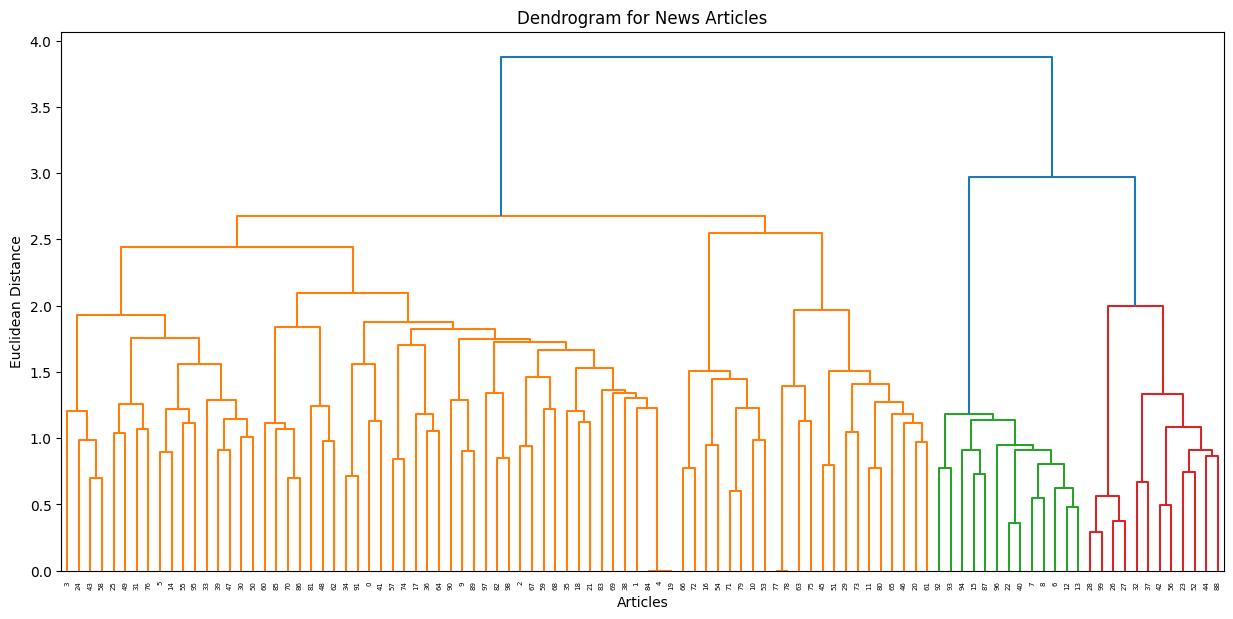

In [ ]:
plt.figure(figsize=(15,7))

dendrogram = sch.dendrogram(
    sch.linkage(X_subset, method='ward')
)
plt.axhline(y=180,color='r',linestyle='--')
plt.title("Dendrogram for News Articles")
plt.xlabel("Articles")
plt.ylabel("Euclidean Distance")
plt.show()

**Apply Hierarchical Clustering**

Use Agglomerative Hierarchical Clustering
Choose an appropriate linkage method

In [ ]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(
    n_clusters=4,
    linkage='ward'
)
y_hc = hc.fit_predict(X.toarray())

In [ ]:
df['cluster'] = y_hc
df.head()

,sentiment,text,cluster
0,neutral,Technopolis plans to develop in stages an area...,2
1,negative,The international electronic industry company ...,2
2,positive,With the new production plant the company woul...,1
3,positive,According to the company 's updated strategy f...,2
4,positive,FINANCING OF ASPOCOMP 'S GROWTH Aspocomp is ag...,2


In [ ]:
df['cluster'].value_counts()

,count
cluster,
2,3113
1,1066
0,409
3,257


In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

X_dense = X.toarray()
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_dense)


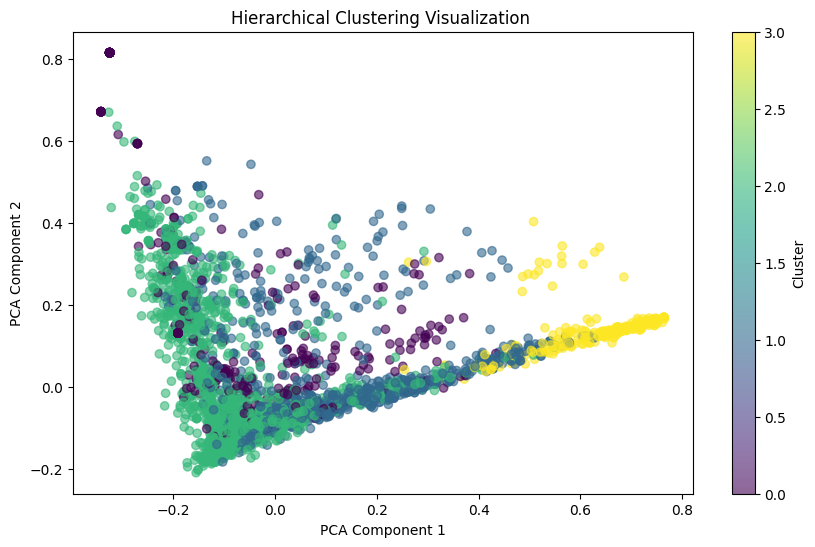

In [ ]:
plt.figure(figsize=(10,6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y_hc,
    cmap='viridis',
    alpha=0.6
)

plt.title("Hierarchical Clustering Visualization ")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(label="Cluster")
plt.show()


In [ ]:
from sklearn.metrics import silhouette_score
score = silhouette_score(X_dense, y_hc)

print("Silhouette Score:", score)

Silhouette Score: 0.05921131062803977
